# K-Nearest Neighbor Classification – Breast Cancer Diagnostic Tool

### Objective
Build a K-Nearest Neighbor (KNN) classifier to diagnose breast cancer tumors as malignant or benign. We will scale numerical features, use cross-validation to tune the hyperparameter $k$, and evaluate the model using precision, recall, and a confusion matrix.

### Step 1: Environment Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Load the built-in Breast Cancer dataset
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target # 0 = Malignant, 1 = Benign

print(f"Dataset Shape: {df.shape}")
print("Missing Values:\n", df.isnull().sum().sum())

Dataset Shape: (569, 31)
Missing Values:
 0


In [2]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Calculate correlation of all features to the target
correlations = df.corr()['target'].sort_values(ascending=False)

print("--- Top 5 Positive Correlations ---")
print(correlations.head(5))

print("\n--- Top 5 Negative Correlations ---")
print(correlations.tail(5))

--- Top 5 Positive Correlations ---
target                    1.000000
smoothness error          0.067016
mean fractal dimension    0.012838
texture error             0.008303
symmetry error            0.006522
Name: target, dtype: float64

--- Top 5 Negative Correlations ---
mean perimeter         -0.742636
worst radius           -0.776454
mean concave points    -0.776614
worst perimeter        -0.782914
worst concave points   -0.793566
Name: target, dtype: float64


### Step 2: Exploratory Data Analysis & Splitting
Since this is a built-in dataset, there are zero missing values. To understand our data, we will visualize the distribution of two key features (mean radius and mean texture) grouped by the target class. 

After exploring, we will split our data into an 80% Training set and a 20% Testing set to ensure an unbiased evaluation.

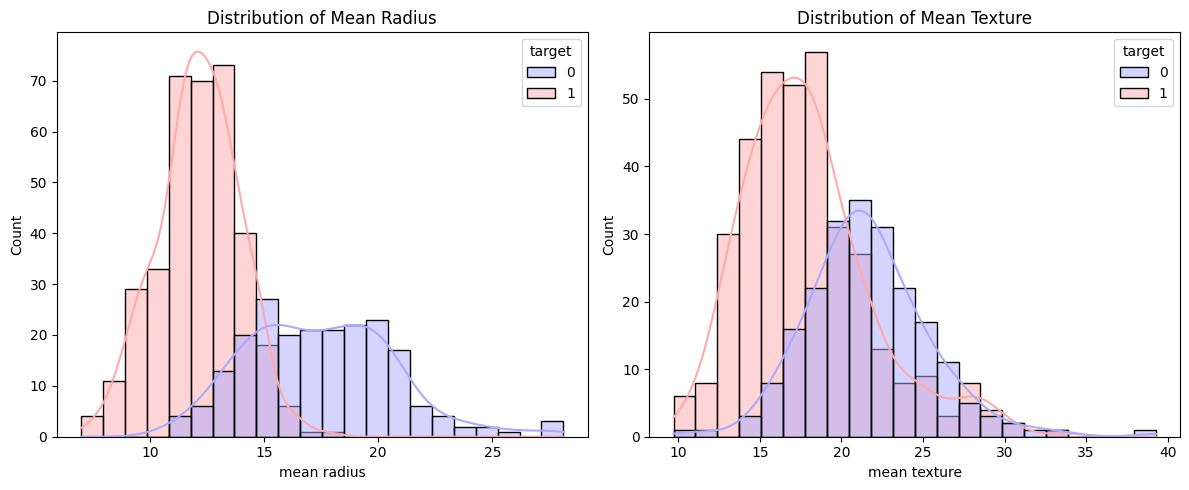

In [3]:
# Visualize feature distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='mean radius', hue='target', kde=True, palette='bwr')
plt.title('Distribution of Mean Radius')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='mean texture', hue='target', kde=True, palette='bwr')
plt.title('Distribution of Mean Texture')
plt.tight_layout()
plt.show()

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 3: Feature Scaling & Cross-Validation for Optimal 'k'

**Why scaling is mandatory for KNN:** KNN relies on calculating the physical distance (Euclidean distance) between data points. If one feature is measured in thousands (like area) and another in decimals (like symmetry), the larger numbers will completely dominate the distance math. `StandardScaler` squishes all features to a mean of 0 and variance of 1, leveling the playing field.

After scaling, we will test multiple $k$ values using 5-fold cross-validation to find the optimal number of neighbors.

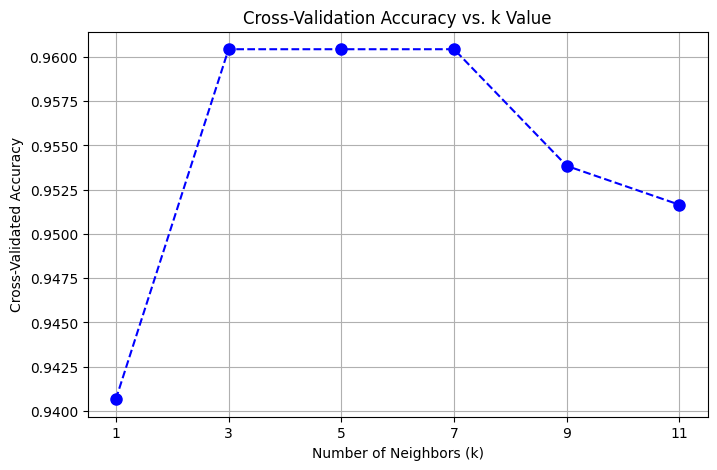

The optimal value for k is: 5


In [5]:
# Initialize and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only to prevent data leakage!

# Test different k values
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold cross-validation
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot k vs. Accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed', color='blue', markersize=8)
plt.title('Cross-Validation Accuracy vs. k Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the best k
optimal_k = k_values[cv_scores.index(max(cv_scores))]
print(f"The optimal value for k is: {optimal_k}")

### Step 4: Final Model Evaluation & New Sample Prediction
Using our optimal $k$ value, we will train the final model and evaluate its performance on our unseen testing data. We will also pass a completely synthetic "new patient" data point to see how the model categorizes it.

Final Model Accuracy: 0.9474

--- Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       0.93      0.93      0.93        43
   Benign (1)       0.96      0.96      0.96        71

     accuracy                           0.95       114
    macro avg       0.94      0.94      0.94       114
 weighted avg       0.95      0.95      0.95       114



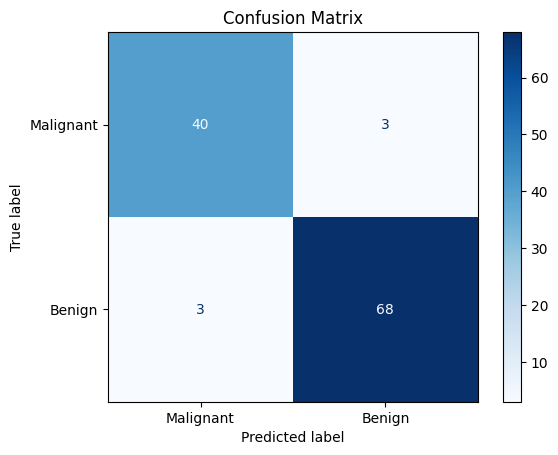

Prediction for the new average sample point: Benign


c:\Users\KABIR\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [6]:
# Train final model with optimal k
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = final_knn.predict(X_test_scaled)

# Evaluation Metrics
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Test prediction on a new synthetic sample (using the mean of the dataset as a baseline)
new_sample = np.array(X.mean()).reshape(1, -1)
new_sample_scaled = scaler.transform(new_sample)
prediction = final_knn.predict(new_sample_scaled)

result = "Benign" if prediction[0] == 1 else "Malignant"
print(f"Prediction for the new average sample point: {result}")